<h1 style="text-align: center;">Data Visualization with Matplotlib & Seaborn 🎨</h1>

<font size="4">In data science, visualization is a critical tool for:</font> 

- <font size="4">Exploration: Quickly spotting outliers, distributions, and patterns.</font>

- <font size="4">Communication: Presenting complex results clearly to an audience.</font>

<font size="4">We will use two libraries:</font>

- <font size="4">**Matplotlib**: The foundation. Powerful and customizable, but requires more code.</font>

- <font size="4">**Seaborn**: Built on top of Matplotlib. Optimized for statistical plots (like correlations and regressions) and looks beautiful by default.</font>

<font size="4">**Setup & First Plot**</font>

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set the aesthetic style (try 'whitegrid', 'darkgrid', 'ticks')
sns.set_theme(style="whitegrid")

np.random.seed(42)

study_hours = np.random.randint(1, 10, 30)

# 2. Create dependent variable (Score) WITH positive correlation
exam_score = np.clip(10 + (4 * study_hours) + np.random.randint(-15, 10, 30), 0, 30)

df = pd.DataFrame({
    'study_hours': study_hours,
    'exam_score': exam_score
})

print(df.corr()) # Check correlation (should be close to 1.0)
print(df.head())

             study_hours  exam_score
study_hours     1.000000    0.775934
exam_score      0.775934    1.000000
   study_hours  exam_score
0            7          30
1            4          17
2            8          30
3            5          23
4            7          29


<font size="4">**Scatter Plot & Regression Plot**</font>

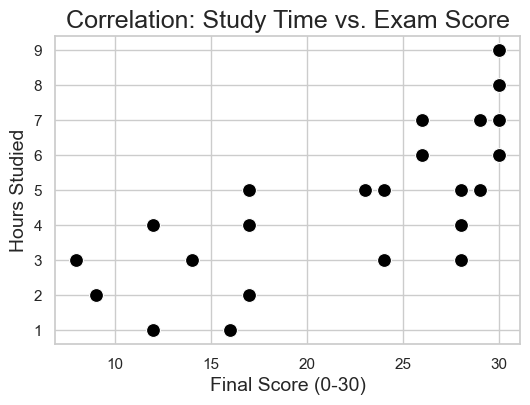

In [36]:
# Create a figure (canvas)
plt.figure(figsize=(6, 4))

# Create the plot using Seaborn
sns.scatterplot(data=df, x='exam_score', y='study_hours', s=100, color='black')

# Customizing with Matplotlib
plt.title("Correlation: Study Time vs. Exam Score", fontsize=18)
plt.xlabel("Final Score (0-30)", fontsize=14)
plt.ylabel("Hours Studied", fontsize=14)

# Show the plot
plt.show()

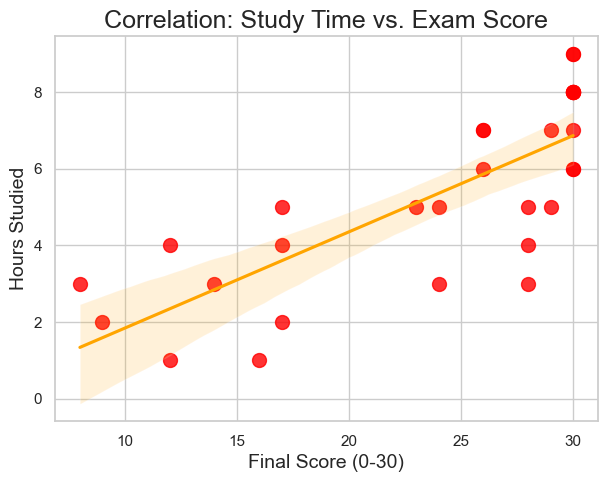

In [39]:
plt.figure(figsize=(7, 5))
sns.regplot(
    data=df,
    x='exam_score',
    y='study_hours',
    scatter_kws={'s': 100, 'color': 'red'},
    line_kws={'color': 'orange'},
    ci=95  # set to None if you don't want the confidence intervals
)

plt.title("Correlation: Study Time vs. Exam Score", fontsize=18)
plt.xlabel("Final Score (0-30)", fontsize=14)
plt.ylabel("Hours Studied", fontsize=14)
plt.show()

<font size="4">**The Histogram & Density Plot (Distribution)**</font>

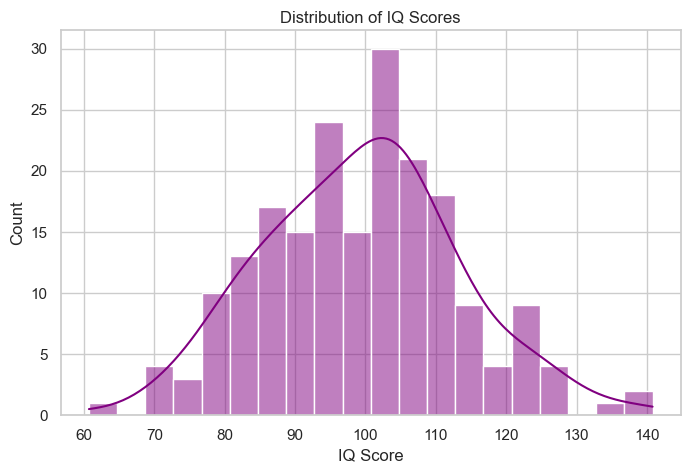

In [42]:
# Generate random normal data (e.g., IQ scores)
np.random.seed(42)
iq_scores = np.random.normal(loc=100, scale=15, size=200) # Mean=100, SD=15

plt.figure(figsize=(8, 5))

# histplot combines a Histogram (bars) with a KDE (smooth line)
sns.histplot(iq_scores, kde=True, color='purple', bins=20)

plt.title("Distribution of IQ Scores")
plt.xlabel("IQ Score")
plt.show()

<font size="4">**The Box Plot (Group Comparison)**</font>

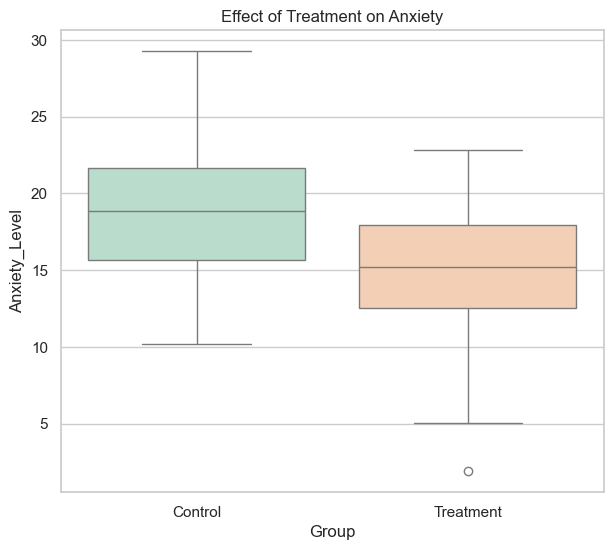

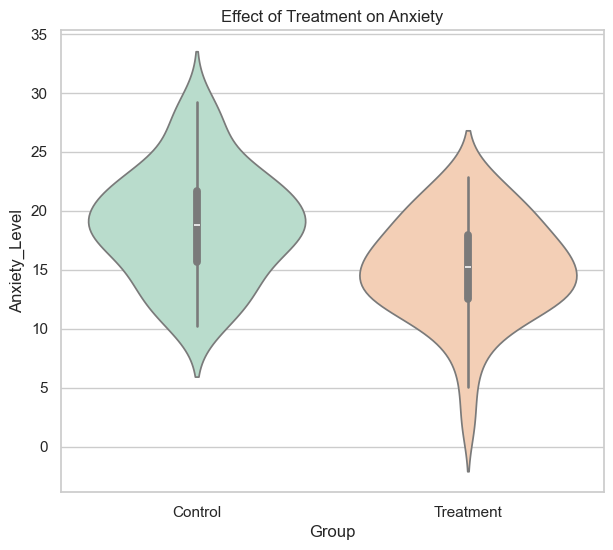

In [55]:
# Simulated experiment data
np.random.seed(42)
df_exp = pd.DataFrame({
    'Group': ['Control']*50 + ['Treatment']*50,
    'Anxiety_Level': np.concatenate([np.random.normal(20, 5, 50), np.random.normal(15, 5, 50)])
})

plt.figure(figsize=(7, 6))
sns.boxplot(data=df_exp, x='Group', y='Anxiety_Level', palette="Pastel2", hue='Group', legend=False)

plt.title("Effect of Treatment on Anxiety")
plt.show()

## The Violin plot
plt.figure(figsize=(7, 6))
sns.violinplot(data=df_exp, x='Group', y='Anxiety_Level', palette="Pastel2", inner="box", hue = 'Group', legend=False)
plt.title("Effect of Treatment on Anxiety")
plt.show()

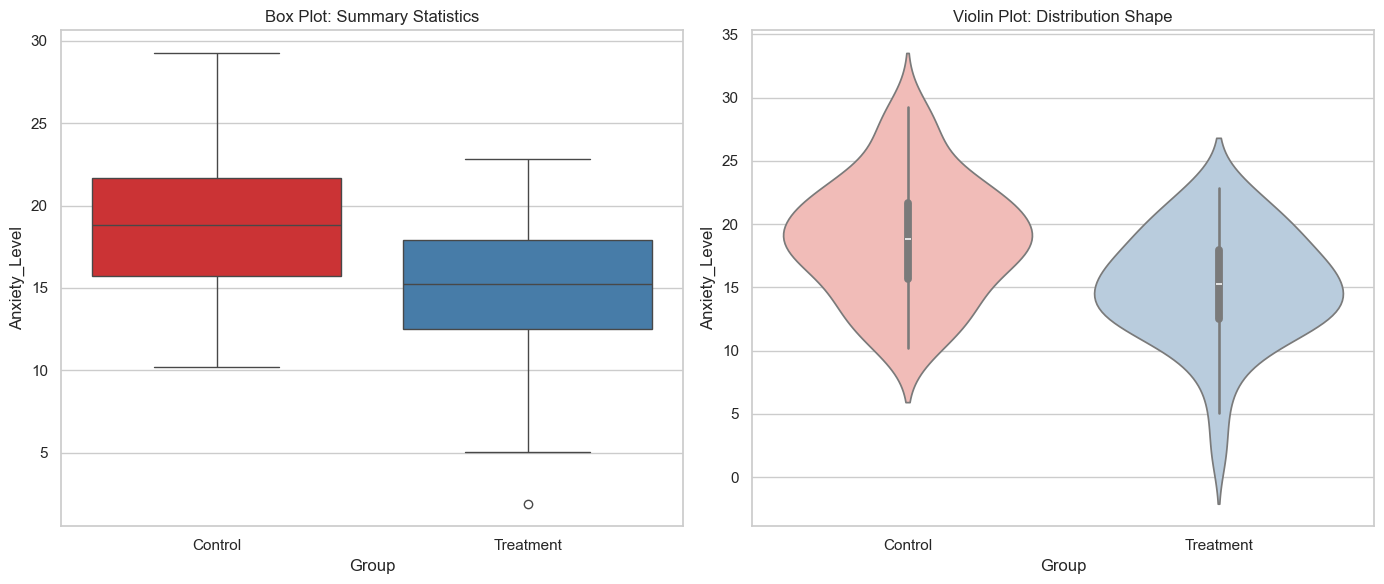

In [54]:
# 2. Create a Figure with 2 Subplots (1 Row, 2 Columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Box Plot (Left) ---
sns.boxplot(
    data=df_exp, 
    x='Group', 
    y='Anxiety_Level', 
    palette="Set1", 
    hue='Group', 
    legend=False, 
    ax=axes[0]  # Place on the first subplot
)
axes[0].set_title("Box Plot: Summary Statistics")

# --- Plot 2: Violin Plot (Right) ---
sns.violinplot(
    data=df_exp, 
    x='Group', 
    y='Anxiety_Level', 
    palette="Pastel1", 
    inner="box", 
    hue='Group', 
    legend=False, 
    ax=axes[1]  # Place on the second subplot
)
axes[1].set_title("Violin Plot: Distribution Shape")

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

<font size="4">**The Bar Plot (Categorical Means)**</font>

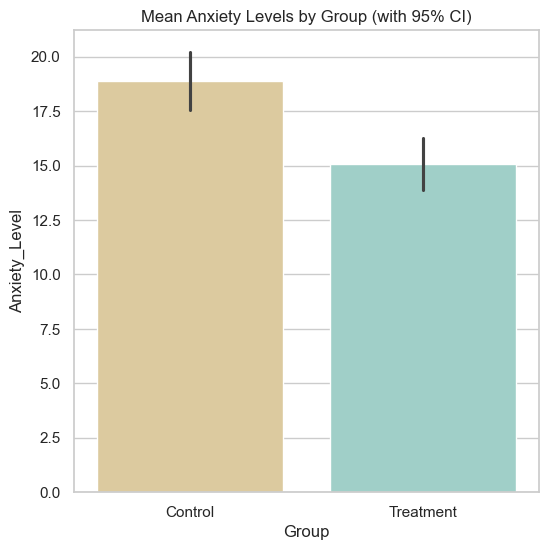

In [59]:
plt.figure(figsize=(6, 6))
# 'barplot' calculates the mean automatically
sns.barplot(data=df_exp, x='Group', y='Anxiety_Level', errorbar='ci', palette="BrBG", hue='Group', legend=False)

plt.title("Mean Anxiety Levels by Group (with 95% CI)")
plt.show()


<font size="4">**Saving Plots**</font>

<font size="4">You often need to save high-quality images for papers or slides.

Plot saved as 'example_plot.png'


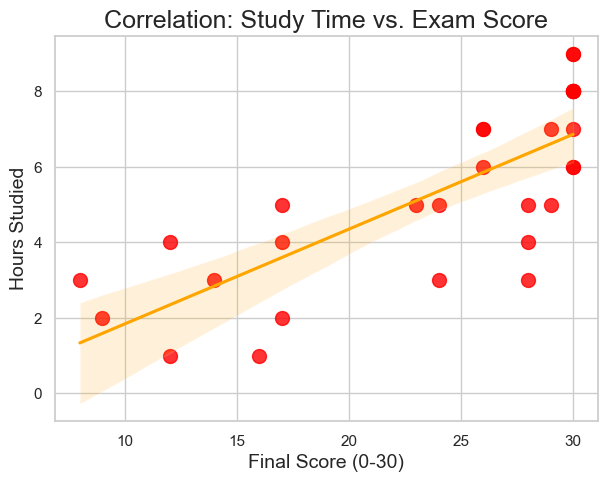

In [72]:
fig, ax = plt.subplots(figsize=(7, 5)) # Fig is a permanent object
sns.regplot(
    data=df,
    x='exam_score',
    y='study_hours',
    scatter_kws={'s': 100, 'color': 'red'},
    line_kws={'color': 'orange'},
    ci=95  # set to None if you don't want the confidence intervals
)

plt.title("Correlation: Study Time vs. Exam Score", fontsize=18)
plt.xlabel("Final Score (0-30)", fontsize=14)
plt.ylabel("Hours Studied", fontsize=14)

# Save as PNG (good for slides) or PDF/SVG 
fig.savefig("example_plot.png", dpi=300, bbox_inches='tight')
print("Plot saved as 'example_plot.png'")

# 2. Display the plot in the notebook (this clears the figure!)
plt.show()

In [75]:
# ---------------------------------------------------------
# EXERCISE 8: Visualization Challenge
# ---------------------------------------------------------

# 0. Setup: Create the Dataset
np.random.seed(99)
df_sleep = pd.DataFrame({
    'Participant': range(1, 61),
    'Condition': ['Normal']*30 + ['Sleep_Deprived']*30,
    'Reaction_Time_ms': np.concatenate([
        np.random.normal(250, 30, 30),  # Normal: Mean 250ms, SD 30
        np.random.normal(350, 40, 30)   # Deprived: Mean 350ms, SD 40
    ]),
    'Errors': np.concatenate([
        np.random.randint(0, 3, 30),    # Normal: 0-2 errors
        np.random.randint(2, 8, 30)     # Deprived: 2-7 errors
    ])
})

# 1. Histogram: Check the distribution of 'Reaction_Time_ms'
#    Use sns.histplot(). Is it roughly normal?
#    Hint: Use kde=True to see the curve.

# ... write your code here ...


# 2. Box Plot: Compare 'Reaction_Time_ms' between the two 'Condition' groups.
#    This helps us see the difference in medians and spot any outliers.
#    Hint: x='Condition', y='Reaction_Time_ms'.

# ... write your code here ...


# 3. Scatter Plot: Is there a relationship between 'Reaction_Time_ms' and 'Errors'?
#    Do slower participants make more mistakes?
#    Hint: Use sns.scatterplot(). Try adding hue='Condition' to color-code the groups!

# ... write your code here ...


# 4. Save your Scatter Plot as a 'sleep_study_results.png' file with 500 dpi.

# ... write your code here ...


<details> 
<summary>Click here to see the solution 💡</summary> 
    <br> 
    <b> Solution:</b> 
    <pre> 

<font size="2">**1. Histogram**</font> 

plt.figure(figsize=(8, 5)) 
sns.histplot(data=df_sleep, x='Reaction_Time_ms', kde=True, color='skyblue') 
plt.title("Distribution of Reaction Times")
plt.show()

<font size="2">**2. Box Plot (Comparison)**</font>
plt.figure(figsize=(6, 6))
sns.boxplot(data=df_sleep, x='Condition', y='Reaction_Time_ms', palette='pastel', hue='Condition')
plt.title("Effect of Sleep Deprivation on Reaction Time")
plt.show()

<font size="2">**3. Scatter Plot (Correlation)**</font>
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df_sleep, x='Reaction_Time_ms', y='Errors', hue='Condition', style='Condition', s=100)
plt.title("Relationship between Speed and Accuracy")
plt.xlabel("Reaction Time (ms)")
plt.ylabel("Number of Errors")
plt.legend(title='Sleep Condition')
plt.show()

<font size="2">**4. Saving**</font>
fig.savefig("sleep_study_results.png", dpi=300)
</pre>


<p><i><b>Interpretation:</b> The Box Plot should clearly show that the "Sleep Deprived" group has a higher median reaction time (slower). The Scatter Plot likely shows a positive trend: as reaction time increases (slower), errors tend to increase, and the Sleep Deprived group clusters in the top-right (slow & error-prone).</i></p> </details>